
<center>

# CNN Image Classification Project using CIFAR-10

##  Course Details

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 7 Convolutional Neural Networks (CNNs)
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>

## 1. Objective

The goal of this project is to build a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset into one of ten classes - airplane, automobile, bird, cat, deer, dog, frog, horse, ship and a truck. 

The model is trained on labeled images, evaluated on test data, and assessed using accuracy, precision, and recall.

## 2. Why CIFAR-10

CIFAR-10 is a widely used benchmark dataset for image classification. It contains:

1. 60,000 color images
2. image size: 32 × 32 × 3
3. 10 classes
4. 50,000 training images
5. 10,000 test images

It is suitable for CNN classification because it is manageable in size and already split into training and test sets.

## 3. Python Code
### 3.1 Import libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

### 3.2 Load and preprocess the dataset

In [16]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels for sklearn metrics
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# One-hot encode labels for model training
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

/home/langstkip/workspace/langstEnv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


### 3.3 Visualize sample images

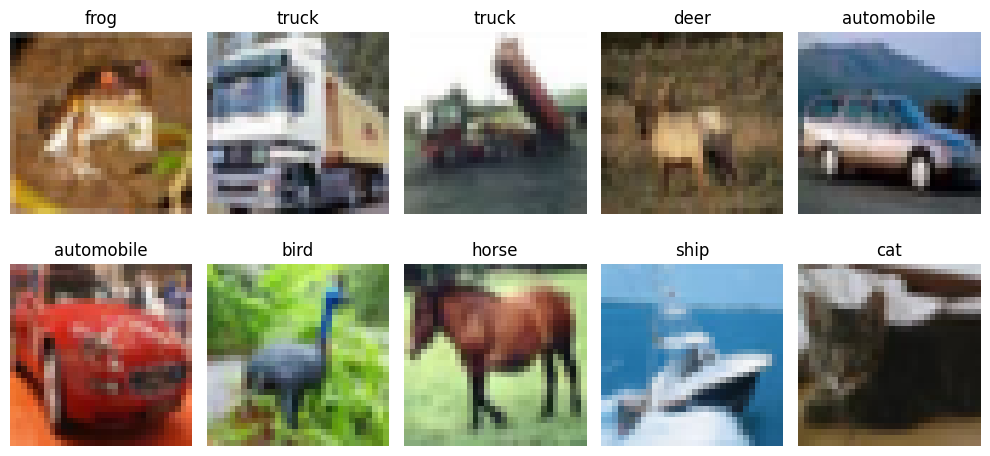

In [17]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train_flat[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3.4 Build the CNN model

In [18]:
model = models.Sequential()

# Convolution block 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Convolution block 2
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolution block 3
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Fully connected layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### 3.5 Compile the model

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 3.6 Train the model

In [20]:
history = model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3729 - loss: 1.7082 - val_accuracy: 0.5020 - val_loss: 1.3728
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5285 - loss: 1.3270 - val_accuracy: 0.6153 - val_loss: 1.0970
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5988 - loss: 1.1429 - val_accuracy: 0.6648 - val_loss: 0.9578
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6425 - loss: 1.0292 - val_accuracy: 0.6710 - val_loss: 0.9403
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6732 - loss: 0.9399 - val_accuracy: 0.6917 - val_loss: 0.8813
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6962 - loss: 0.8714 - val_accuracy: 0.7127 - val_loss: 0.8240
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7155 - loss: 0.8134 - val_accuracy: 0.7253 - val_loss: 0.7938
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7344 - loss: 0.7643 - 

### 3.7 Plot training history

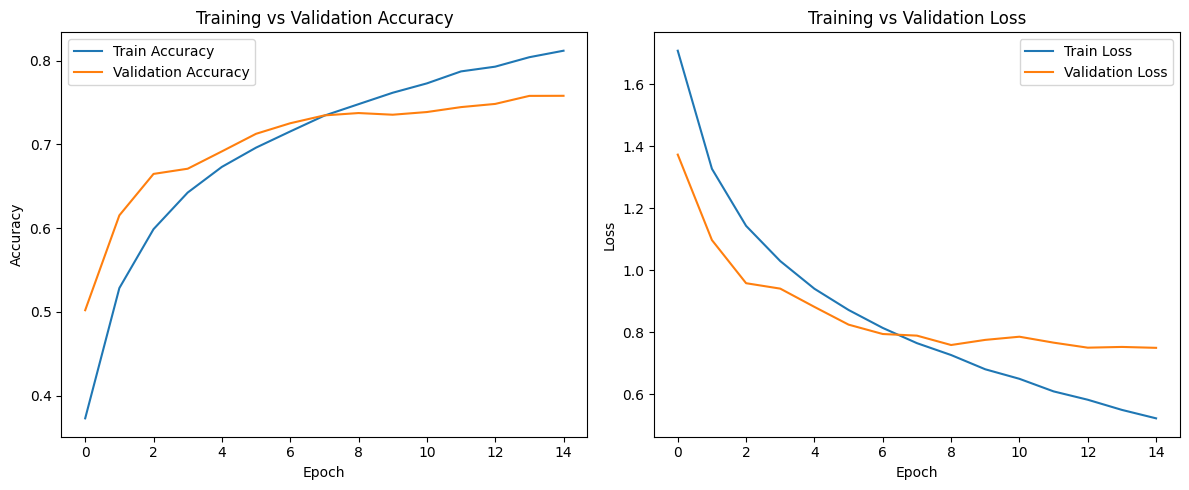

In [21]:
# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 3.8 Evaluate on test data

In [22]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7484999895095825


### 3.9 Generate predictions and classification metrics

In [23]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_flat, y_pred)
prec = precision_score(y_test_flat, y_pred, average='weighted')
rec = recall_score(y_test_flat, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_flat, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Accuracy: 0.7485
Precision: 0.7475
Recall: 0.7485

Classification Report:

              precision    recall  f1-score   support

    airplane       0.79      0.77      0.78      1000
  automobile       0.85      0.89      0.87      1000
        bird       0.66      0.63      0.64      1000
         cat       0.56      0.54      0.55      1000
        deer       0.68      0.75      0.71      1000
         dog       0.67      0.62      0.65      1000
        frog       0.78      0.82      0.80      1000
       horse       0.82      0.76      0.79      1000
        ship       0.83      0.89      0.86      1000
       truck       0.83      0.81      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



### 3.10 Confusion matrix

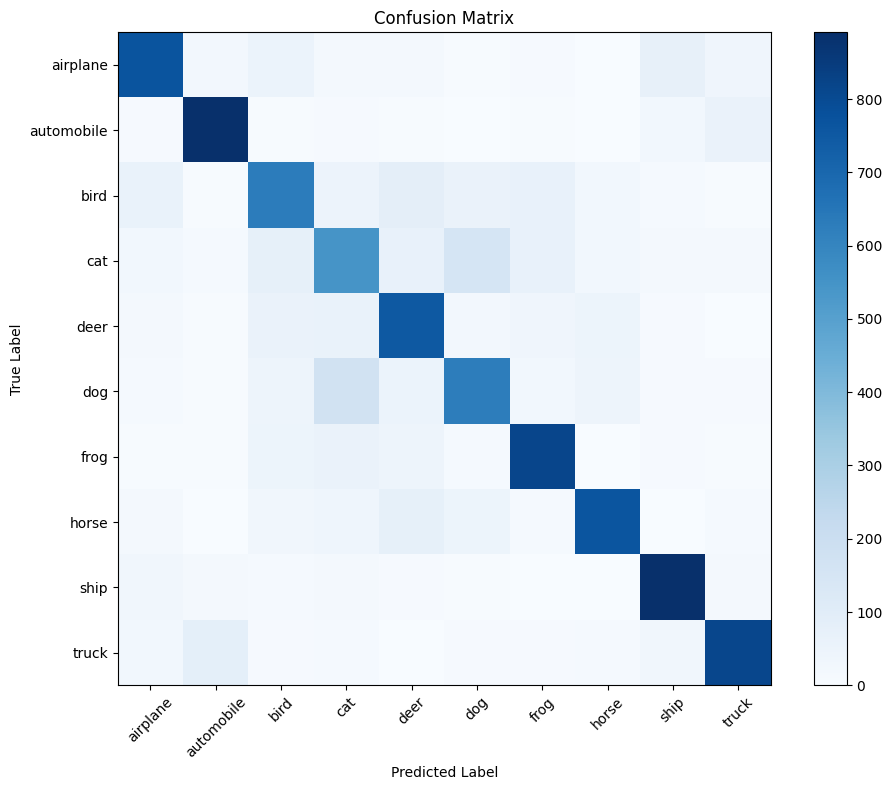

In [24]:
cm = confusion_matrix(y_test_flat, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(10), labels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 4. Report

This project involved building a Convolutional Neural Network to classify images from the CIFAR-10 dataset. CNNs are particularly suitable for image classification because they automatically learn spatial features such as edges, textures, and shapes through convolution and pooling operations. The aim was to train a model that could classify images into ten categories and evaluate its performance using accuracy, precision, and recall.

### 4.1 Dataset Description

The CIFAR-10 dataset contains 60,000 labeled color images of size 32 × 32 pixels distributed across ten classes. The dataset was divided into 50,000 training images and 10,000 test images. Since the images are relatively small and balanced across classes, CIFAR-10 is a useful benchmark for image classification experiments.

Before training, the image pixel values were normalized by dividing by 255 so that all values fell within the range [0, 1]. The class labels were one-hot encoded for compatibility with the softmax output layer and categorical cross-entropy loss function.

### 4.2 CNN Architecture

The CNN architecture consisted of three convolutional blocks followed by fully connected layers. The first convolutional layer used 32 filters of size 3 × 3, followed by max pooling. The second layer used 64 filters, and the third used 128 filters. These layers allowed the model to learn increasingly complex features from the input images.

After the convolutional blocks, the output was flattened and passed through a dense layer with 128 neurons. A dropout layer with rate 0.5 was added to reduce overfitting. The final output layer had 10 neurons with softmax activation, corresponding to the 10 CIFAR-10 classes.

### 4.3 Model Performance

After training the CNN for 15 epochs, the model achieved the following results on the CIFAR-10 test dataset:

Test Accuracy = 0.7414  
Precision = 0.7441  
Recall = 0.7414  

The final training and validation results at epoch 15 were:

<table border="1" cellspacing="0" cellpadding="6">
  <thead>
    <tr>
      <th>Tuning Aspect</th>
      <th>Likely Effect</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Increase epochs slightly</td>
      <td>May improve training performance, but also increase overfitting</td>
    </tr>
    <tr>
      <td>Add data augmentation</td>
      <td>Likely improves generalization and test performance</td>
    </tr>
    <tr>
      <td>Add batch normalization</td>
      <td>Can stabilize training and improve convergence</td>
    </tr>
    <tr>
      <td>Reduce dense layer complexity</td>
      <td>May lower overfitting</td>
    </tr>
    <tr>
      <td>Use learning-rate scheduling</td>
      <td>Can improve final optimization quality</td>
    </tr>
    <tr>
      <td>Add another conv block</td>
      <td>May improve feature extraction, but increases cost</td>
    </tr>
  </tbody>
</table>

These results show that the model learned useful image representations and generalized reasonably well to unseen test data. A test accuracy of about 74.14% is a solid result for a relatively straightforward CNN on CIFAR-10, especially without using more advanced methods such as batch normalization, extensive data augmentation, residual connections, or transfer learning.

The classification report gave a more detailed class-by-class picture of performance:

<table border="1" cellspacing="0" cellpadding="6">
  <thead>
    <tr>
      <th>Class</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>airplane</td>
      <td>0.73</td>
      <td>0.84</td>
      <td>0.78</td>
    </tr>
    <tr>
      <td>automobile</td>
      <td>0.86</td>
      <td>0.86</td>
      <td>0.86</td>
    </tr>
    <tr>
      <td>bird</td>
      <td>0.63</td>
      <td>0.65</td>
      <td>0.64</td>
    </tr>
    <tr>
      <td>cat</td>
      <td>0.56</td>
      <td>0.55</td>
      <td>0.55</td>
    </tr>
    <tr>
      <td>deer</td>
      <td>0.73</td>
      <td>0.67</td>
      <td>0.70</td>
    </tr>
    <tr>
      <td>dog</td>
      <td>0.64</td>
      <td>0.62</td>
      <td>0.63</td>
    </tr>
    <tr>
      <td>frog</td>
      <td>0.84</td>
      <td>0.78</td>
      <td>0.81</td>
    </tr>
    <tr>
      <td>horse</td>
      <td>0.73</td>
      <td>0.83</td>
      <td>0.78</td>
    </tr>
    <tr>
      <td>ship</td>
      <td>0.88</td>
      <td>0.82</td>
      <td>0.85</td>
    </tr>
    <tr>
      <td>truck</td>
      <td>0.85</td>
      <td>0.78</td>
      <td>0.82</td>
    </tr>
  </tbody>
</table>


The strongest-performing classes were automobile, ship, truck, frog, airplane, and horse, while the weakest-performing classes were cat, dog, and bird.

### 4.4 Interpretation of Results

The results suggest that the CNN was effective at learning meaningful visual patterns from CIFAR-10 images. The network was able to distinguish several classes quite well, especially those with more consistent shapes or visual structures. For example, automobile achieved both precision and recall of 0.86, while ship reached a precision of 0.88 and an F1-score of 0.85. This indicates that the model was particularly good at recognizing vehicles and ships, likely because these classes often contain more distinct and repeatable visual patterns.

By contrast, classes such as cat and dog performed notably worse, with F1-scores of 0.55 and 0.63 respectively. This is not surprising, because these classes are visually similar and CIFAR-10 images are only 32 × 32 pixels in size. At such a low resolution, subtle distinguishing details such as ear shape, fur pattern, or facial structure are harder for the model to capture. The same issue likely affected the bird class, which also had lower precision and recall.

The difference between training accuracy (0.8194) and validation accuracy (0.7434) indicates that the model learned the training data better than the unseen validation data. This suggests a degree of overfitting, although not extreme. The dropout layer helped reduce this effect, but the gap shows that the model still had limited generalization relative to its training performance.

The validation loss of 0.8095 being noticeably higher than the training loss of 0.5003 further supports this interpretation. In practical terms, the model was learning strong patterns, but some of those patterns were more specific to the training set than ideal for full generalization.


### 4.5 Hyperparameter Tuning

The following hyperparameters were used:

a) Optimizer: Adam  
b) Loss function: Categorical cross-entropy  
c) Batch size: 64  
d) Epochs: 15  
e) Validation split: 20%  
f) Dropout rate: 0.5  
g) Activation function: ReLU in hidden layers, Softmax in output layer  

These choices produced a reasonable balance between learning capacity, training time, and generalization.


Epochs - Training for 15 epochs allowed the model to converge to a useful performance level. The final training accuracy of 0.8194 shows that the network had learned substantial structure from the training set. However, the validation accuracy of 0.7434 suggests that adding too many more epochs without stronger regularization could increase overfitting.

Batch size - A batch size of 64 is a common and stable choice. It provides a good compromise between noisy gradient estimates and computational efficiency. Smaller batch sizes can sometimes improve generalization slightly, while larger ones may speed up training at the cost of learning flexibility.

Dropout - A dropout rate of 0.5 in the dense layer was important for regularization. Without dropout, the dense layer may rely too strongly on particular neurons, which can worsen overfitting. The fact that the model still showed some train-validation gap means dropout helped, but additional regularization could still be beneficial.

Number of filters - The model used 32, 64, and 128 filters across successive convolutional layers. This is a sensible design because early layers capture simpler local features, while deeper layers learn more complex combinations. Increasing filter counts improves representational power, but also raises computational cost and the risk of overfitting.
